# **MNIST**

## **1. LIBRERÍAS**





In [14]:
!pip install xgboost

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import struct

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.datasets import fetch_openml

import time

resultados_finales = []

## **2. LIMPIEZA DEL DATASET**

### **2.1 CARGA DEL DATASET Y EXPLORACIÓN DE VARIABLES**


In [16]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=True
)

X = mnist.data
y = mnist.target

print("Dimensiones del dataset:", X.shape)
X.info()
X.describe()

Dimensiones del dataset: (70000, 784)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 784 entries, pixel1 to pixel784
dtypes: int64(784)
memory usage: 418.7 MB


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.0,70000.0,70000.0,70000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.197414,0.099543,0.046629,0.016614,0.012957,0.001714,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.991206,4.256304,2.783732,1.561822,1.553796,0.320889,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.000000,0.0,0.0,0.0,0.0


### **2.2 EXPLORACIÓN DE NULOS Y ELIMINACIÓN DE COLUMNAS IRRELEVANTES**


In [17]:
X.isnull().sum()[X.isnull().sum() > 0].sort_values(ascending=False)

,0


### **2.3 SEPARACIÓN ENTRE X E Y (VARIABLE OBJETIVO)**

In [18]:
y = y.astype(int)
print(y.value_counts())
print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

class
1    7877
7    7293
3    7141
2    6990
9    6958
0    6903
6    6876
8    6825
4    6824
5    6313
Name: count, dtype: int64
Variables predictoras: (70000, 784)
Variable objetivo: (70000,)


### **2.4 DIVISIÓN TRAIN-TEST Y ESCALADO**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

Train: (56000, 784)
Test: (14000, 784)


### **2.4 FUNCIÓN DE EVALUACIÓN PARA TODOS LOS MODELOS**

In [20]:
def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    resultados = {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-score": f1_score(y_test, y_pred, average="weighted")
    }

    print(f"\n===== {nombre_modelo} =====")
    print(classification_report(y_test, y_pred))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

    return resultados

## **3. REGRESION LOGÍSTICA**

### **3.1 DEFINICIÓN DE PARÁMETROS**

In [21]:
inicio_lr = time.time()

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### **3.2 PREDICCIONES Y MÉTRICAS**

In [22]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:,1]
tiempo_lr = time.time() - inicio_lr

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average="weighted")
recall = recall_score(y_test, y_pred_lr, average="weighted")
f1 = f1_score(y_test, y_pred_lr, average="weighted")
print("===== Regresión logística =====")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Tiempo (s):", tiempo_lr)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_lr))

resultados_finales.append({
    "Modelo": "Regresión Logística",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Tiempo (s)": tiempo_lr
})

===== Regresión logística =====
Accuracy: 0.9207857142857143
Precision: 0.9205033188899506
Recall: 0.9207857142857143
F1-score: 0.9205682355750613
Tiempo (s): 104.70971322059631

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.95      0.97      0.96      1575
           2       0.93      0.90      0.91      1398
           3       0.90      0.89      0.89      1428
           4       0.93      0.92      0.93      1365
           5       0.88      0.87      0.88      1263
           6       0.94      0.96      0.95      1375
           7       0.93      0.95      0.94      1459
           8       0.89      0.88      0.89      1365
           9       0.90      0.89      0.89      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



### **3.3 MATRIZ DE CONFUSIÓN**

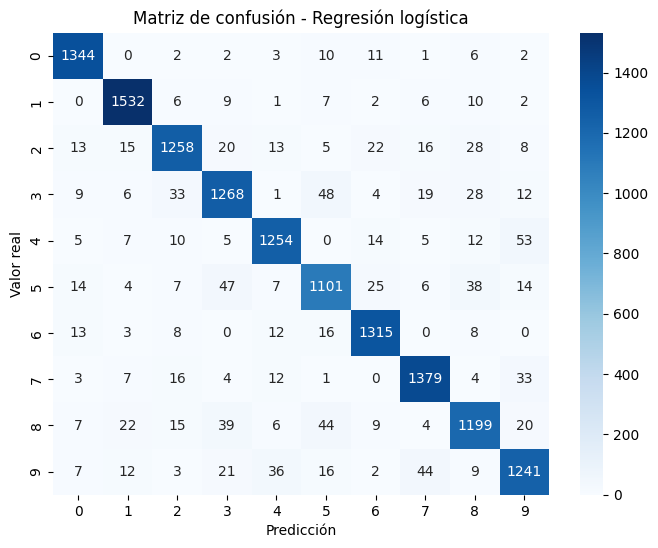

In [23]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Matriz de confusión - Regresión logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

### **3.4 IMPORTANCIA DE VARIABLES**

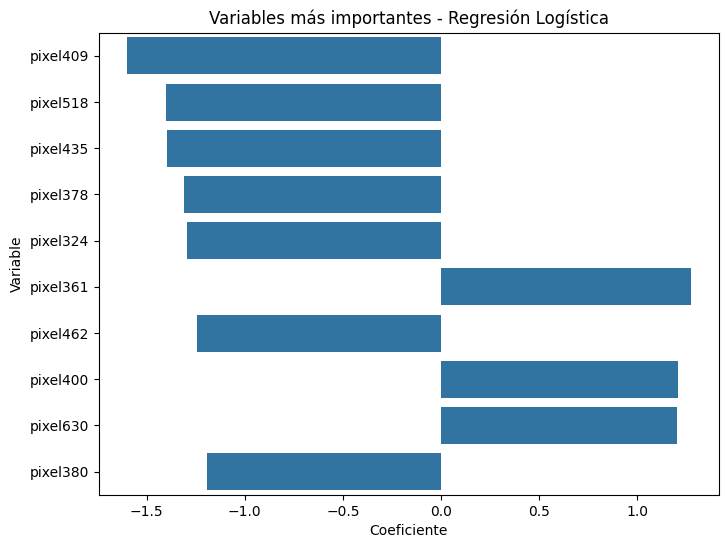

In [24]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_reg.coef_[0]
})

coeficientes["Valor absoluto"] = abs(coeficientes["Coeficiente"])
coeficientes = coeficientes.sort_values(
    by="Valor absoluto",
    ascending=False
)
top10 = coeficientes.head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    data=top10,
    x="Coeficiente",
    y="Variable"
)
plt.title("Variables más importantes - Regresión Logística")
plt.show()

## **4. k-NEAREST NEIGHBORS (k-NN)**

### **4.1 DEFINICIÓN DE PARÁMETROS**

In [25]:
inicio_knn = time.time()
resultados_knn = []

for k in range(1, 31):
    knn = KNeighborsClassifier(
        n_neighbors=k
    )
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    resultados_knn.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(
            y_test,
            y_pred,
            average="weighted"
        )
    })
resultados_knn_df = pd.DataFrame(resultados_knn)
mejor_k = resultados_knn_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["k"]

print("Mejor valor de k:", mejor_k)

Mejor valor de k: 3.0


### **4.2 PREDICCIONES Y MÉTRICAS**

In [26]:
knn_final = KNeighborsClassifier(n_neighbors=int(mejor_k))
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)
y_prob_knn = knn_final.predict_proba(X_test_scaled)[:, 1]
tiempo_knn = time.time() - inicio_knn

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average="weighted")
recall_knn = recall_score(y_test, y_pred_knn, average="weighted")
f1_knn = f1_score(y_test, y_pred_knn, average="weighted")

print("===== k-NN =====")
print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1-score:", f1_knn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

resultados_finales.append({
    "Modelo": "k-NN",
    "Accuracy": accuracy_knn,
    "Precision": precision_knn,
    "Recall": recall_knn,
    "F1-score": f1_knn,
    "Tiempo (s)": tiempo_knn
})

===== k-NN =====
Accuracy: 0.9714285714285714
Precision: 0.9716487572870605
Recall: 0.9714285714285714
F1-score: 0.9713883859190537

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1381
           1       0.96      0.99      0.98      1575
           2       0.99      0.96      0.97      1398
           3       0.97      0.97      0.97      1428
           4       0.98      0.96      0.97      1365
           5       0.97      0.96      0.96      1263
           6       0.98      0.98      0.98      1375
           7       0.97      0.98      0.97      1459
           8       0.99      0.94      0.96      1365
           9       0.95      0.97      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



### **4.3 MATRIZ DE CONFUSIÓN**

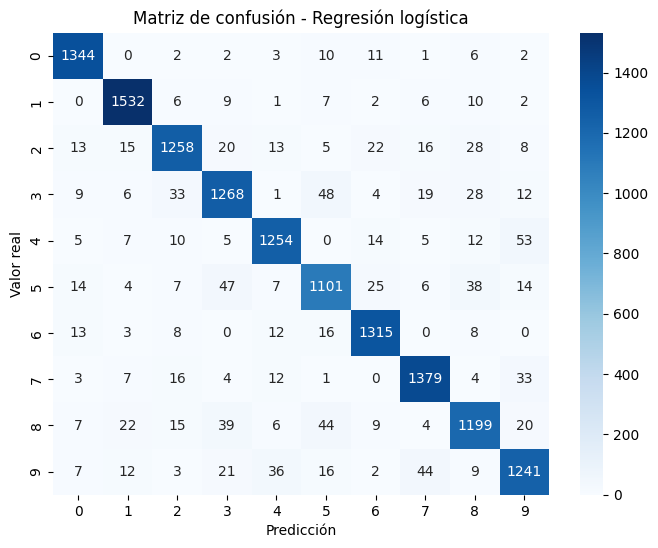

In [27]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Matriz de confusión - Regresión logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## **5. ÁRBOLES DE DECISIÓN**

### **5.1 DEFINICIÓN DE PARÁMETROS**




In [28]:
inicio_tree = time.time()

resultados_tree = []

valores_depth = [10, 20, 30]

for depth in valores_depth:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    y_pred = tree.predict(X_test)

    resultados_tree.append({
        "max_depth": depth,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(
            y_test,
            y_pred,
            average="weighted"
        )
    })

resultados_tree_df = pd.DataFrame(resultados_tree)

mejor_depth = resultados_tree_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["max_depth"]

print("Mejor profundidad:", mejor_depth)

tree_final = DecisionTreeClassifier(
    max_depth=int(mejor_depth),
    random_state=42
)

tree_final.fit(X_train, y_train)

Mejor profundidad: 20.0


DecisionTreeClassifier(max_depth=20, random_state=42)

### **5.2 PREDICCIONES Y MÉTRICAS**

In [29]:
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:,1]
tiempo_tree = time.time() - inicio_tree

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree, average="weighted")
recall_tree = recall_score(y_test, y_pred_tree, average="weighted")
f1_tree = f1_score(y_test, y_pred_tree, average="weighted")

print("===== ÁRBOL DE DECISIÓN =====\n")
print("Accuracy:", accuracy_tree)
print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-score:", f1_tree)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_tree))


resultados_finales.append({
    "Modelo": "Árbol de Decisión",
    "Accuracy": accuracy_tree,
    "Precision": precision_tree,
    "Recall": recall_tree,
    "F1-score": f1_tree,
    "Tiempo (s)": tiempo_tree
})

===== ÁRBOL DE DECISIÓN =====

Accuracy: 0.8737857142857143
Precision: 0.873605907573102
Recall: 0.8737857142857143
F1-score: 0.8736313773345139

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      1381
           1       0.95      0.96      0.95      1575
           2       0.85      0.86      0.86      1398
           3       0.85      0.84      0.84      1428
           4       0.86      0.87      0.87      1365
           5       0.82      0.83      0.82      1263
           6       0.90      0.88      0.89      1375
           7       0.90      0.91      0.90      1459
           8       0.84      0.81      0.82      1365
           9       0.82      0.82      0.82      1391

    accuracy                           0.87     14000
   macro avg       0.87      0.87      0.87     14000
weighted avg       0.87      0.87      0.87     14000



### **5.3 MATRIZ DE CONFUSIÓN**

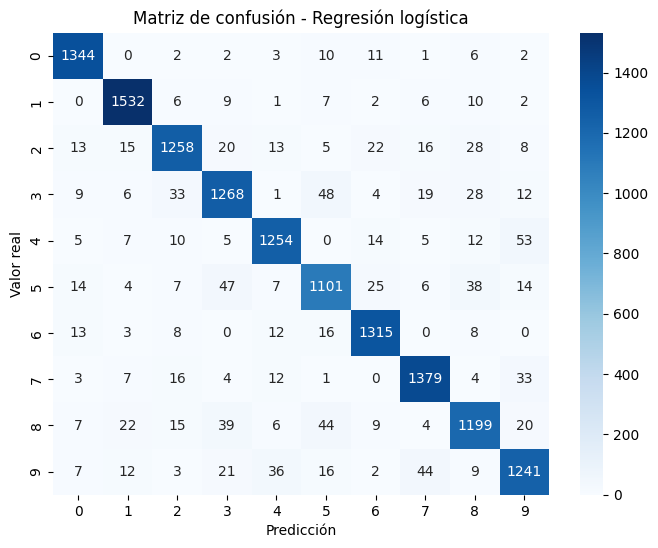

In [30]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Matriz de confusión - Regresión logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

### **5.4 IMPORTANCIA DE VARIABLES**

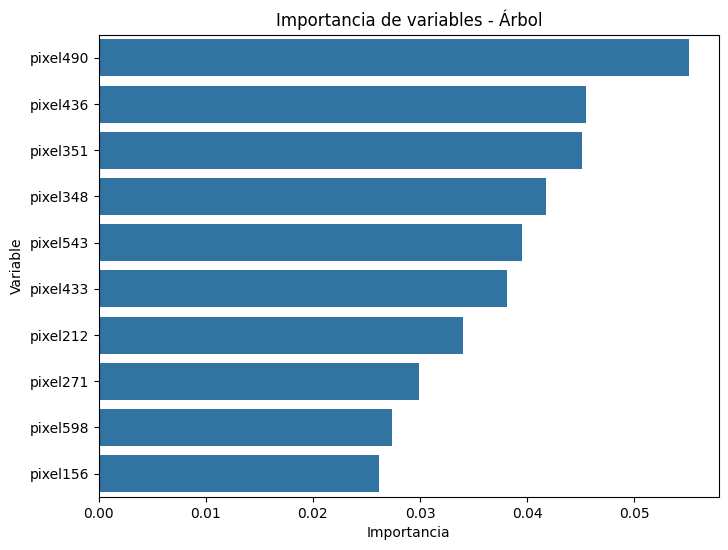

In [31]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": tree.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias.head(10)
top10 = importancias.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Árbol")

plt.show()

## **6. RANDOM FOREST**

### **6.1 DEFINICIÓN DE PARÁMETROS**

In [32]:
inicio_rf = time.time()

resultados_rf = []

valores_estimators = [50, 100, 200, 300]

for n in valores_estimators:

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    resultados_rf.append({
        "n_estimators": n,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(
            y_test,
            y_pred,
            average="weighted"
        )
    })

resultados_rf_df = pd.DataFrame(resultados_rf)

mejor_n = resultados_rf_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]["n_estimators"]


rf_final = RandomForestClassifier(
    n_estimators=int(mejor_n),
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

### **6.2 PREDICCIONES Y MÉTRICAS**

In [33]:
y_pred_rf = rf_final.predict(X_test)
tiempo_rf = time.time() - inicio_rf

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average="weighted")
recall_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("===== RANDOM FOREST =====\n")

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_rf))

resultados_finales.append({
    "Modelo": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-score": f1_rf,
    "Tiempo (s)": tiempo_rf
})

===== RANDOM FOREST =====

Accuracy: 0.9687142857142857
Precision: 0.9687249535713363
Recall: 0.9687142857142857
F1-score: 0.9686976268488753

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.97      0.97      0.97      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.96      0.97      1365
           5       0.97      0.96      0.97      1263
           6       0.97      0.98      0.98      1375
           7       0.98      0.97      0.97      1459
           8       0.96      0.96      0.96      1365
           9       0.95      0.95      0.95      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



### **6.3 MATRIZ DE CONFUSIÓN**

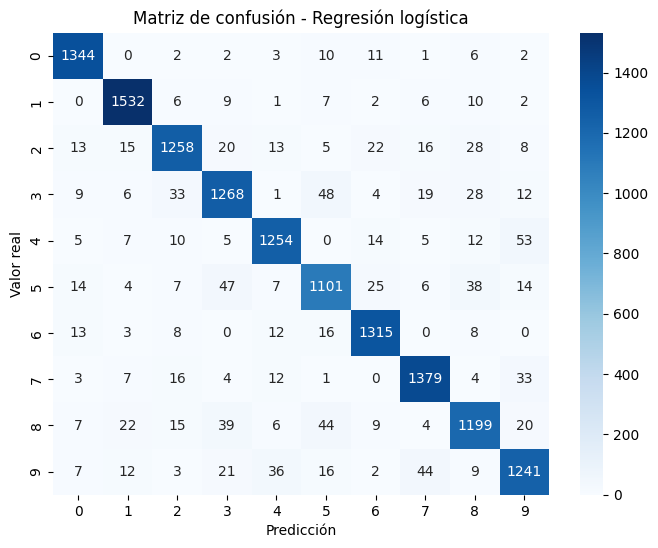

In [34]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Matriz de confusión - Regresión logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

### **6.4 IMPORTANCIA DE VARIABLES**

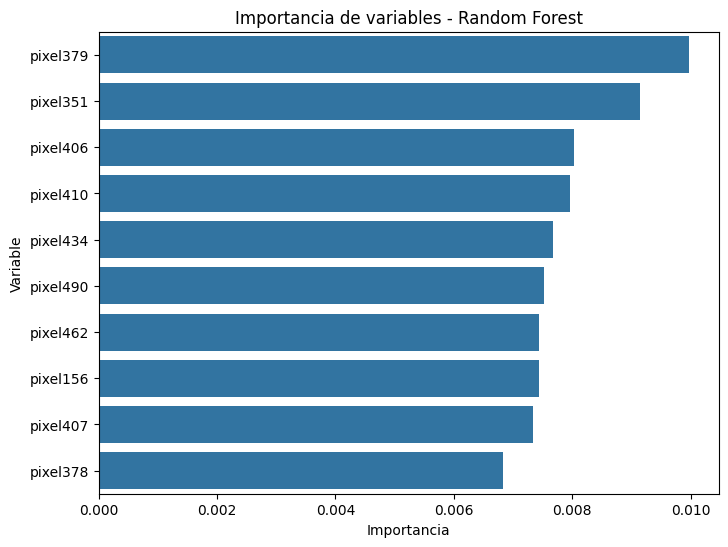

In [35]:
importancias_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importancias_rf = importancias_rf.sort_values(
    by="Importancia",
    ascending=False
)

top10_rf = importancias_rf.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10_rf,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## **7. XGBOOST**

### **7.1 DEFINICIÓN DE PARÁMETROS**

In [36]:
inicio_xgb = time.time()

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [200],
    "learning_rate": [0.1],
    "max_depth": [7],
    "subsample": [0.8],
    "colsample_bytree": [1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=20,
    scoring="f1_weighted",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(xgb_search.best_params_)

xgb_final = xgb_search.best_estimator_

Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=20. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Mejores hiperparámetros:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


### **7.2 PREDICCIONES Y MÉTRICAS**

In [37]:
y_pred_xgb = xgb_final.predict(X_test)
tiempo_xgb = time.time() - inicio_xgb

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average="weighted")
recall_xgb = recall_score(y_test, y_pred_xgb, average="weighted")
f1_xgb = f1_score(y_test, y_pred_xgb, average="weighted")

print("===== XGBOOST =====\n")

print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1-score:", f1_xgb)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_xgb))

resultados_finales.append({
    "Modelo": "XGBoost",
    "Accuracy": accuracy_xgb,
    "Precision": precision_xgb,
    "Recall": recall_xgb,
    "F1-score": f1_xgb,
    "Tiempo (s)": tiempo_xgb
})

===== XGBOOST =====

Accuracy: 0.9760714285714286
Precision: 0.9760828670741917
Recall: 0.9760714285714286
F1-score: 0.976061420179738

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.97      0.97      0.97      1398
           3       0.97      0.97      0.97      1428
           4       0.98      0.97      0.97      1365
           5       0.98      0.97      0.98      1263
           6       0.98      0.99      0.98      1375
           7       0.98      0.98      0.98      1459
           8       0.97      0.97      0.97      1365
           9       0.96      0.96      0.96      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



### **7.3 MATRIZ DE CONFUSIÓN**

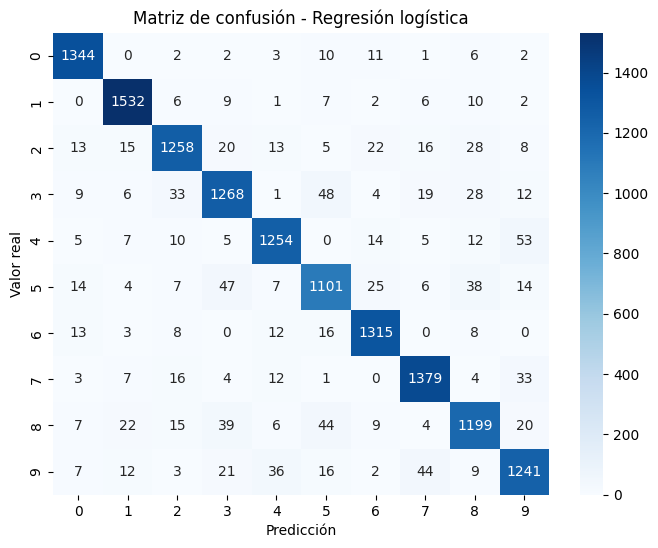

In [38]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Matriz de confusión - Regresión logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

### **7.4 IMPORTANCIA DE VARIABLES**

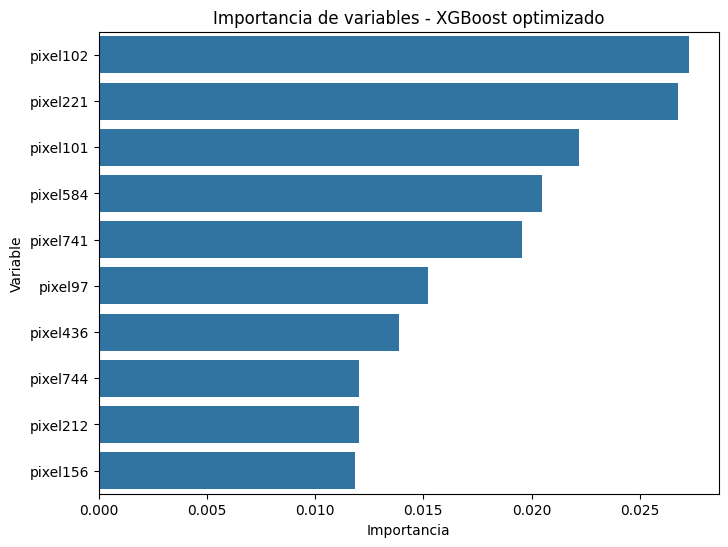

In [39]:
importancias_xgb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": xgb_final.feature_importances_
}).sort_values(by="Importancia", ascending=False)

top10_xgb = importancias_xgb.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10_xgb,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - XGBoost optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## **8. RED NEURONAL**

## **8.1 DIVISIÓN TRAIN-TEST**

In [40]:
inicio_mlp = time.time()

np.random.seed(42)

print("X_train:", X_train_scaled.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test_scaled.shape)
print("y_test:", y_test.shape)

X_train: (56000, 784)
y_train: (56000,)
X_test: (14000, 784)
y_test: (14000,)


## **8.3 DEFINICIÓN DE FUNCIONES:**


*   Definición de la arquitectura de la red
*   Capas ocultas y funciones de activación


*   Batch Normalization
*   Dropout

*   Capa de salida Softmax
*   Optimización del modelo

*   Función de pérdida


*   Regularización y ajuste de hiperparámetros


In [41]:
inicio_mlp = time.time()

def crear_mlp(arquitectura, learning_rate, dropout_rate):

    model = Sequential()

    model.add(Dense(
        arquitectura[0],
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ))

    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    for neurons in arquitectura[1:]:

        model.add(Dense(
            neurons,
            activation="relu"
        ))

        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## **8.4 BÚSQUEDA DE HIPERPARÁMETROS**

In [42]:
resultados_mlp = []

arquitecturas = [
    [64],
    [128, 64],
    [256, 128]
]

learning_rates = [0.01, 0.001]

dropouts = [0.2, 0.3]

batch_sizes = [64, 128]


for arquitectura in arquitecturas:

    for lr in learning_rates:

        for dropout in dropouts:

            for batch_size in batch_sizes:

                inicio_temp = time.time()

                mlp = crear_mlp(
                    arquitectura=arquitectura,
                    learning_rate=lr,
                    dropout_rate=dropout
                )

                early_stop = EarlyStopping(
                    monitor="val_loss",
                    patience=3,
                    restore_best_weights=True
                )

                history = mlp.fit(
                    X_train_scaled,
                    y_train,
                    validation_split=0.2,
                    epochs=10,
                    batch_size=batch_size,
                    callbacks=[early_stop],
                    verbose=0
                )

                y_prob_temp = mlp.predict(
                    X_test_scaled,
                    verbose=0
                )

                y_pred_temp = np.argmax(
                    y_prob_temp,
                    axis=1
                )

                tiempo_temp = time.time() - inicio_temp

                resultados_mlp.append({
                    "Arquitectura": str(arquitectura),
                    "Learning Rate": lr,
                    "Dropout": dropout,
                    "Batch Size": batch_size,
                    "Epochs reales": len(history.history["loss"]),
                    "Accuracy": accuracy_score(y_test, y_pred_temp),
                    "Precision": precision_score(
                        y_test,
                        y_pred_temp,
                        average="weighted"
                    ),
                    "Recall": recall_score(
                        y_test,
                        y_pred_temp,
                        average="weighted"
                    ),
                    "F1-score": f1_score(
                        y_test,
                        y_pred_temp,
                        average="weighted"
                    ),
                    "Tiempo (s)": tiempo_temp
                })
        resultados_mlp_df = pd.DataFrame(resultados_mlp)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

### **8.4.1 Selección del mejor modelo con los hiperparámetros**

In [43]:
mejor_mlp = resultados_mlp_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

print("Mejor configuración encontrada:")
print(mejor_mlp)

best_architecture = eval(mejor_mlp["Arquitectura"])
best_lr = mejor_mlp["Learning Rate"]
best_dropout = mejor_mlp["Dropout"]
best_batch_size = int(mejor_mlp["Batch Size"])

Mejor configuración encontrada:
Arquitectura     [256, 128]
Learning Rate         0.001
Dropout                 0.3
Batch Size               64
Epochs reales            10
Accuracy           0.978786
Precision          0.978792
Recall             0.978786
F1-score           0.978768
Tiempo (s)        33.383497
Name: 22, dtype: object


## **8.5 ENTRENAMIENTO DEL MODELO CON LOS HIPERPARÁMETROS**

In [44]:
mlp_final = crear_mlp(
    arquitectura=best_architecture,
    learning_rate=best_lr,
    dropout_rate=best_dropout
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_mlp = mlp_final.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=best_batch_size,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8961 - loss: 0.3420 - val_accuracy: 0.9586 - val_loss: 0.1389
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9456 - loss: 0.1801 - val_accuracy: 0.9638 - val_loss: 0.1172
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9555 - loss: 0.1413 - val_accuracy: 0.9687 - val_loss: 0.1012
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9637 - loss: 0.1175 - val_accuracy: 0.9719 - val_loss: 0.0889
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9653 - loss: 0.1081 - val_accuracy: 0.9762 - val_loss: 0.0869
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9703 - loss: 0.0946 - val_accuracy: 0.9746 - val_loss: 0.0856
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9723 - loss: 0.0847 - val_accuracy: 0.9743 - val_loss: 0.0779
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9727 - loss: 0.0830 - val_accuracy: 0.

## **8.6 CURVA DE COSTE**

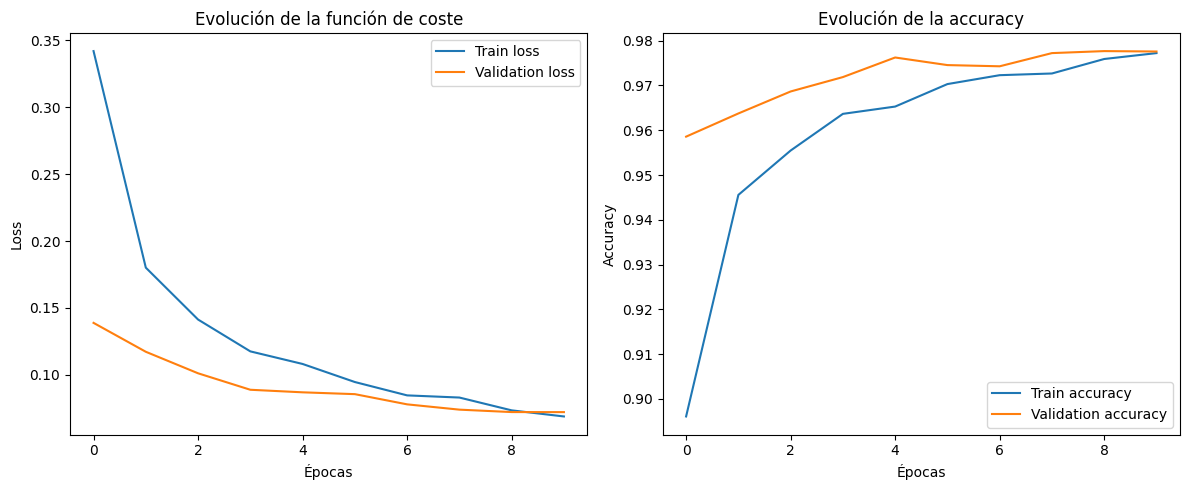

In [45]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_mlp.history["loss"], label="Train loss")
plt.plot(history_mlp.history["val_loss"], label="Validation loss")
plt.title("Evolución de la función de coste")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_mlp.history["accuracy"], label="Train accuracy")
plt.plot(history_mlp.history["val_accuracy"], label="Validation accuracy")
plt.title("Evolución de la accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## **8.7 PREDICCIONES Y MÉTRICAS**

In [46]:
y_prob_mlp = mlp_final.predict(X_test_scaled)

y_pred_mlp = np.argmax(
    y_prob_mlp,
    axis=1
)

tiempo_mlp = time.time() - inicio_mlp

accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

precision_mlp = precision_score(
    y_test,
    y_pred_mlp,
    average="weighted"
)

recall_mlp = recall_score(
    y_test,
    y_pred_mlp,
    average="weighted"
)

f1_mlp = f1_score(
    y_test,
    y_pred_mlp,
    average="weighted"
)

print("===== RED NEURONAL MLP - MNIST =====\n")

print("Mejor arquitectura:", best_architecture)
print("Learning rate:", best_lr)
print("Dropout:", best_dropout)
print("Batch size:", best_batch_size)

print("\nAccuracy:", accuracy_mlp)
print("Precision:", precision_mlp)
print("Recall:", recall_mlp)
print("F1-score:", f1_mlp)
print("Tiempo (s):", tiempo_mlp)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_mlp))

resultados_finales.append({
    "Modelo": "Red Neuronal MLP",
    "Accuracy": accuracy_mlp,
    "Precision": precision_mlp,
    "Recall": recall_mlp,
    "F1-score": f1_mlp,
    "Tiempo (s)": tiempo_mlp
})

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
===== RED NEURONAL MLP - MNIST =====

Mejor arquitectura: [256, 128]
Learning rate: 0.001
Dropout: 0.3
Batch size: 64

Accuracy: 0.9771428571428571
Precision: 0.9771586799465258
Recall: 0.9771428571428571
F1-score: 0.9771115710454011
Tiempo (s): 678.3392219543457

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1381
           1       0.98      0.99      0.98      1575
           2       0.98      0.97      0.98      1398
           3       0.98      0.97      0.97      1428
           4       0.97      0.98      0.98      1365
           5       0.98      0.97      0.97      1263
           6       0.98      0.99      0.98      1375
           7       0.98      0.98      0.98      1459
           8       0.97      0.98      0.97      1365
           9       0.98      0.95      0.96      1391

    accuracy                           0.98     14000
   macro 

## **8.8 MATRIZ DE CONFUSIÓN Y CURVA ROC**

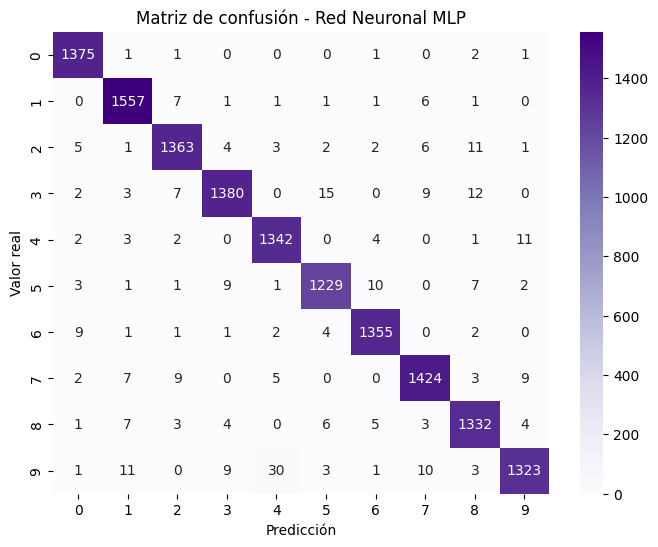

In [47]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Matriz de confusión - Red Neuronal MLP")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# **9. COMPARACIÓN DE MODELOS**

In [48]:
tabla_resultados = pd.DataFrame(resultados_finales)

tabla_resultados["Interpretabilidad"] = [
    "Sí",   # Regresión Logística
    "No",   # k-NN
    "Sí",   # Árbol
    "Sí",   # Random Forest
    "Sí",   # XGBoost
    "No"    # Red neuronal
]

tabla_resultados = tabla_resultados.sort_values(
    by="F1-score",
    ascending=False
)

tabla_resultados = tabla_resultados.reset_index(drop=True)

tabla_resultados.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,Tiempo (s),Interpretabilidad
0,Red Neuronal MLP,0.9771,0.9772,0.9771,0.9771,678.3392,No
1,XGBoost,0.9761,0.9761,0.9761,0.9761,2412.6643,Sí
2,k-NN,0.9714,0.9716,0.9714,0.9714,1166.1389,No
3,Random Forest,0.9687,0.9687,0.9687,0.9687,355.0607,Sí
4,Regresión Logística,0.9208,0.9205,0.9208,0.9206,104.7097,Sí
5,Árbol de Decisión,0.8738,0.8736,0.8738,0.8736,64.0628,Sí
